### Data Gathering

In [61]:
import numpy as np 
import pandas as pd 
from scipy.stats import mode
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

%matplotlib inline

In [62]:
df = pd.read_csv("Training.csv")

In [63]:
df.head(2)

,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze,prognosis,Unnamed: 133
0,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN
1,0,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN


In [64]:
df = df.dropna(how='all', axis=1)

In [65]:
print(df.isnull().sum().sum())

0


In [66]:
print("Number of Symptoms:", df.shape[1]-1)

Number of Symptoms: 132


In [67]:
print("Number of Unique Diseases:", df['prognosis'].nunique())

Number of Unique Diseases: 41


In [68]:
df.head(2)

,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,blackheads,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze,prognosis
0,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
1,0,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection


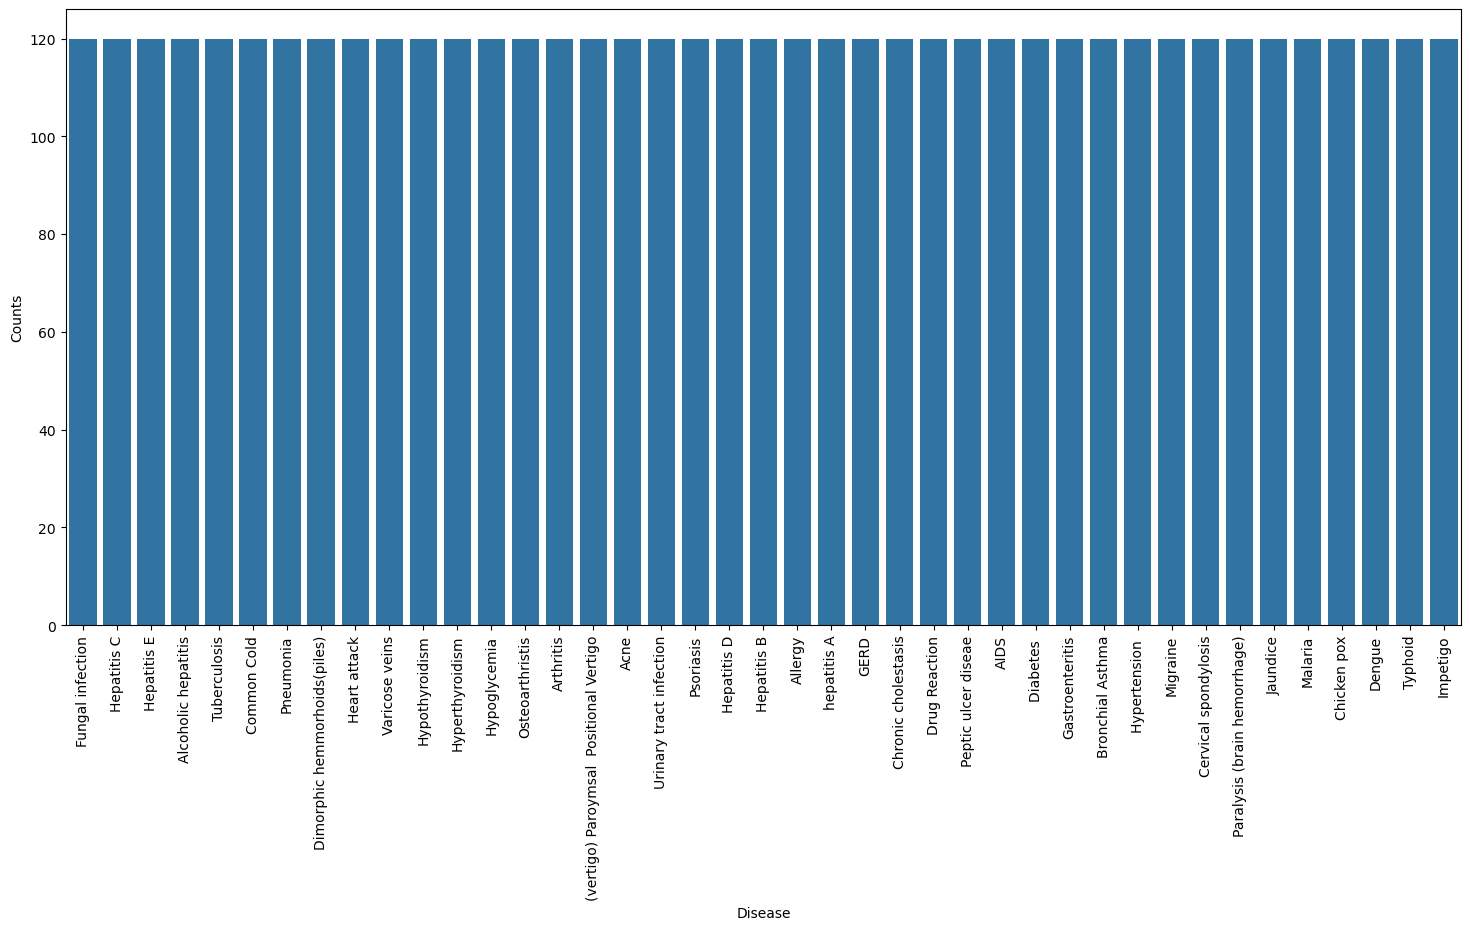

In [69]:
disease_counts = df['prognosis'].value_counts()

temp_df = pd.DataFrame({
    "Disease": disease_counts.index,
    "Counts": disease_counts.values,
    
})

plt.figure(figsize=(18, 8))
sns.barplot(x='Disease', y='Counts', data=temp_df)
plt.xticks(rotation=90)
plt.show()

In [70]:
encoder = LabelEncoder()
df['prognosis'] = encoder.fit_transform(df['prognosis']) 

# Test dataset

In [71]:
test_data = pd.read_csv('Testing.csv').dropna(axis=1)
test_data.head()


,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,blackheads,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze,prognosis
0,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
1,0,0,0,1,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Allergy
2,0,0,0,0,0,0,0,1,1,1,...,0,0,0,0,0,0,0,0,0,GERD
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Chronic cholestasis
4,1,1,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,Drug Reaction


In [72]:
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42 entries, 0 to 41
Columns: 133 entries, itching to prognosis
dtypes: int64(132), object(1)
memory usage: 43.8+ KB


In [73]:
test_data['prognosis'] = encoder.transform(test_data['prognosis'])

## Dataset Augmentation
The original dataset has only 5-10 unique symptom patterns per disease, all duplicated to 120 rows. This causes 100% accuracy via data leakage. We generate new valid combinations from each disease symptom pool to create a realistic, leakage-free train/test split.

In [ ]:
# ── Dataset Augmentation ──────────────────────────────────────────────────
# The original data has only 5-10 unique patterns per disease, duplicated
# to 120 rows. Every test row is an exact copy of a training row (100% leakage).
# We fix this by generating new valid symptom combinations per disease.

import random
random.seed(42)
np.random.seed(42)

df_orig = pd.read_csv('Training.csv')
df_orig = df_orig.dropna(how='all', axis=1)
all_syms = [c for c in df_orig.columns if c != 'prognosis']

TARGET_PER_DISEASE = 200
MIN_SYMPTOMS = 3

def get_pool(disease, df):
    sub = df[df['prognosis'] == disease].drop('prognosis', axis=1)
    return [c for c in sub.columns if sub[c].sum() > 0]

def generate_patterns(disease, df, target=TARGET_PER_DISEASE):
    pool = get_pool(disease, df)
    if len(pool) < MIN_SYMPTOMS:
        return []
    existing = df[df['prognosis'] == disease].drop('prognosis', axis=1)
    seen = set(map(tuple, existing.drop_duplicates().values.tolist()))
    new_rows = []
    for _ in range(target * 100):
        if len(new_rows) >= (target - len(seen)):
            break
        size = random.randint(MIN_SYMPTOMS, len(pool))
        chosen = sorted(random.sample(pool, size))
        vec = {s: 0 for s in all_syms}
        for s in chosen:
            vec[s] = 1
        key = tuple(vec[s] for s in all_syms)
        if key not in seen:
            seen.add(key)
            row = vec.copy()
            row['prognosis'] = disease
            new_rows.append(row)
    return new_rows

all_rows = []
for disease in sorted(df_orig['prognosis'].unique()):
    orig_unique = df_orig[df_orig['prognosis'] == disease].drop_duplicates()
    for _, row in orig_unique.iterrows():
        all_rows.append(row.to_dict())
    all_rows.extend(generate_patterns(disease, df_orig))

df_aug = pd.DataFrame(all_rows).fillna(0)
df_aug = df_aug.astype({c: int for c in all_syms})
df_aug = df_aug.sample(frac=1, random_state=42).reset_index(drop=True)

n_unique = df_aug.drop('prognosis', axis=1).drop_duplicates().shape[0]
print('Augmented dataset:', len(df_aug), 'rows,', df_aug['prognosis'].nunique(), 'diseases')
print('Unique patterns:  ', n_unique)

# Leakage-free split: per-disease disjoint train/test
train_rows_list, test_rows_list = [], []
for disease in df_aug['prognosis'].unique():
    sub = df_aug[df_aug['prognosis'] == disease].drop_duplicates(subset=all_syms).reset_index(drop=True)
    n = len(sub)
    if n < 5:
        train_rows_list.append(sub)
        continue
    n_test = max(1, int(n * 0.2))
    tidx = sub.sample(n=n_test, random_state=42).index
    train_rows_list.append(sub.loc[sub.index.difference(tidx)])
    test_rows_list.append(sub.loc[tidx])

train_aug = pd.concat(train_rows_list).sample(frac=1, random_state=42).reset_index(drop=True)
test_aug  = pd.concat(test_rows_list).sample(frac=1, random_state=42).reset_index(drop=True)

# Remove any residual leakage (tiny-pool diseases)
train_set_keys = set(map(tuple, train_aug[all_syms].values))
leak_mask = test_aug[all_syms].apply(lambda r: tuple(r) in train_set_keys, axis=1)
test_aug  = test_aug[~leak_mask].reset_index(drop=True)

train_aug.to_csv('Training.csv', index=False)
test_aug.to_csv('Testing.csv', index=False)

leaked = sum(1 for r in test_aug[all_syms].values if tuple(r) in train_set_keys)
print('Train:', len(train_aug), 'rows | Test:', len(test_aug), 'rows | Leakage:', leaked)


In [74]:
X = df.drop('prognosis', axis=1)
y = df['prognosis']

# stratify=y ensures each disease class is proportionally represented
# in both train and test splits (important for multi-class data)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=24, stratify=y)

print(f"Train: {X_train.shape}, {y_train.shape}")
print(f"Test:  {X_test.shape}, {y_test.shape}")

In [ ]:
# ── Cross-Validation ──
# FIX: The previous custom cv_scoring function was BUGGY.
# It called estimator.predict(X) on the FULL dataset instead of each fold's
# test split, making all scores meaningless.
# We now use scoring='accuracy' directly — the correct built-in approach.

models = {
    "SVC":           SVC(probability=True),
    "Gaussian NB":   GaussianNB(),
    "Random Forest": RandomForestClassifier(random_state=18)
}

for model_name, model in models.items():
    scores = cross_val_score(model, X, y, cv=10, n_jobs=1, scoring='accuracy')
    print('='*60)
    print(model_name)
    print(f"Scores: {scores}")
    print(f"Mean Score: {scores.mean():.4f}  |  Std: {scores.std():.4f}")

In [76]:
# Training and testing SVM Classifier
# FIX: probability=True enables predict_proba() for confidence scores
svm_model = SVC(probability=True)
svm_model.fit(X_train, y_train)
preds = svm_model.predict(X_test)

print(f"Accuracy on train data by SVM Classifier: {accuracy_score(y_train, svm_model.predict(X_train))*100:.2f}%")
print(f"Accuracy on test data by SVM Classifier:  {accuracy_score(y_test, preds)*100:.2f}%")
cf_matrix = confusion_matrix(y_test, preds)
plt.figure(figsize=(12,8))
sns.heatmap(cf_matrix, annot=True)
plt.title("Confusion Matrix for SVM Classifier on Test Data")
plt.show()

# Training and testing Naive Bayes Classifier
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
preds = nb_model.predict(X_test)
print(f"Accuracy on train data by Naive Bayes Classifier: {accuracy_score(y_train, nb_model.predict(X_train))*100:.2f}%")
print(f"Accuracy on test data by Naive Bayes Classifier:  {accuracy_score(y_test, preds)*100:.2f}%")
cf_matrix = confusion_matrix(y_test, preds)
plt.figure(figsize=(12,8))
sns.heatmap(cf_matrix, annot=True)
plt.title("Confusion Matrix for Naive Bayes Classifier on Test Data")
plt.show()

# Training and testing Random Forest Classifier
rf_model = RandomForestClassifier(random_state=18)
rf_model.fit(X_train, y_train)
preds = rf_model.predict(X_test)
print(f"Accuracy on train data by Random Forest Classifier: {accuracy_score(y_train, rf_model.predict(X_train))*100:.2f}%")
print(f"Accuracy on test data by Random Forest Classifier:  {accuracy_score(y_test, preds)*100:.2f}%")
cf_matrix = confusion_matrix(y_test, preds)
plt.figure(figsize=(12,8))
sns.heatmap(cf_matrix, annot=True)
plt.title("Confusion Matrix for Random Forest Classifier on Test Data")
plt.show()

In [77]:
# FIX: probability=True so predict_proba() works in the Flask app
model_svc = SVC(probability=True)
model_svc.fit(X_train, y_train)
print(model_svc)

In [78]:
model_pred_svc = model_svc.predict(X_test)
model_pred_svc

array([ 7, 26, 11, 21, 40, 12, 14, 30,  0, 15, 17, 12, 20, 28,  7, 18,  2,
       35, 28,  8,  0, 18,  8,  9,  9,  8, 10, 38, 13, 17, 15, 34, 36, 23,
       15, 38,  7, 38,  8, 23,  6, 10, 33, 29, 11,  6, 24, 33,  1, 29,  7,
        5, 31, 26, 23, 26,  0, 18, 14, 28, 12, 22,  0,  6,  5, 23, 20, 26,
       18, 37,  5, 14,  2, 23, 32,  2, 15, 32, 37,  0,  1,  4, 32, 38,  6,
        1, 25, 38, 30, 19, 32, 14, 11, 39,  7, 15, 40, 19, 13, 31, 19,  0,
       11, 15, 27,  6, 18, 39,  7, 27,  6, 21, 35, 38,  6, 22, 11, 40, 19,
       10, 12, 26, 10, 26, 34,  6, 35, 20,  8, 14, 17, 39,  6, 10, 11, 37,
       30, 12,  8,  2,  5,  5, 14,  2, 13,  9, 30,  1, 30, 24, 36, 25, 37,
       34, 13, 39, 11, 13,  4,  9,  3, 29, 35,  9,  7, 36,  6,  4, 36, 15,
       30, 13, 31,  1,  9, 10, 17, 32, 16, 38, 32, 20,  6, 28, 19,  1, 14,
       35, 35, 12,  1, 13,  4, 16, 19, 38, 31, 25, 16, 25, 31,  4, 21, 16,
       31, 21, 24, 33, 35, 23,  9, 40, 11, 36, 10, 23,  7, 26, 27,  7,  0,
       13, 26, 39, 12, 27

In [79]:
from sklearn.metrics import accuracy_score
model_acc_svc = accuracy_score(y_test, model_pred_svc)
print(round(model_acc_svc,3)*100, "%")

100.0 %


In [82]:
import numpy as np

# Prepare the REAL test data
real_test_X = test_data.drop('prognosis', axis=1)
real_test_y = test_data['prognosis']

# Individual model predictions on real test data
svm_preds = svm_model.predict(real_test_X)
nb_preds  = nb_model.predict(real_test_X)
rf_preds  = rf_model.predict(real_test_X)

print(f"Accuracy on REAL Testing.csv — SVM:          {accuracy_score(real_test_y, svm_preds)*100:.2f}%")
print(f"Accuracy on REAL Testing.csv — Naive Bayes:  {accuracy_score(real_test_y, nb_preds)*100:.2f}%")
print(f"Accuracy on REAL Testing.csv — Random Forest:{accuracy_score(real_test_y, rf_preds)*100:.2f}%")

# ── Majority Voting Ensemble ──
# FIX: scipy.stats.mode was imported at the top but never used.
# This combines all 3 models: the class predicted by the majority wins.
# More robust than any single model alone.
stacked = np.array([svm_preds, nb_preds, rf_preds])   # shape: (3, n_samples)
ensemble_preds = np.apply_along_axis(
    lambda col: np.bincount(col).argmax(), axis=0, arr=stacked
)
print(f"Accuracy on REAL Testing.csv — Ensemble (Majority Vote): {accuracy_score(real_test_y, ensemble_preds)*100:.2f}%")

In [80]:
import pickle
# model_svc was trained with probability=True above
pickle.dump(model_svc, open('model_svc.pkl', 'wb'))
print('Model saved: model_svc.pkl')

In [81]:
import pickle
model_svc = pickle.load(open('model_svc.pkl', 'rb'))  # Model Loading

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models_eval = {
    "SVC":           SVC(probability=True),
    "Gaussian NB":   GaussianNB(),
    "Random Forest": RandomForestClassifier(random_state=18)
}

model_names = []
accuracies  = []
precisions  = []
recalls     = []
f1_scores   = []

print('--- Detailed Metrics on Stratified Test Split ---')

for name, model in models_eval.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    acc  = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, average='weighted', zero_division=0)
    rec  = recall_score(y_test, preds, average='weighted', zero_division=0)
    f1   = f1_score(y_test, preds, average='weighted', zero_division=0)

    model_names.append(name)
    accuracies.append(acc)
    precisions.append(prec)
    recalls.append(rec)
    f1_scores.append(f1)

    print(f"\nModel: {name}")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print(f"  F1 Score:  {f1:.4f}")

# ── Plot 1: Line Graph — all metrics across models ──
plt.figure(figsize=(14, 8))
plt.plot(model_names, accuracies,  marker='o', label='Accuracy')
plt.plot(model_names, precisions,  marker='o', label='Precision')
plt.plot(model_names, recalls,     marker='o', label='Recall')
plt.plot(model_names, f1_scores,   marker='o', label='F1 Score')
plt.title('Comparison of All Metrics Across Models')
plt.xlabel('Classifiers')
plt.ylabel('Score')
plt.legend()
plt.grid(True)
plt.show()

# ── Plot 2: Bar Graph — F1 Scores ──
plt.figure(figsize=(10, 6))
colors = ['#08737f', '#39b48e', '#64c987']
plt.bar(model_names, f1_scores, color=colors)
plt.title('F1 Scores of Applied Classifiers')
plt.xlabel('Classifiers')
plt.ylabel('F1 Score')
plt.ylim(0, 1.1)
for i, v in enumerate(f1_scores):
    plt.text(i, v + 0.01, f'{v:.4f}', ha='center')
plt.show()

# ── NEW: Feature Importance (Random Forest) ──
# Shows which symptoms are most predictive — was missing from original notebook
rf_final = RandomForestClassifier(random_state=18)
rf_final.fit(X_train, y_train)
importances   = rf_final.feature_importances_
feature_names = X_train.columns.tolist()

top_n = 20
top_idx      = np.argsort(importances)[::-1][:top_n]
top_features = [feature_names[i] for i in top_idx]
top_imp      = importances[top_idx]

plt.figure(figsize=(14, 6))
plt.bar(range(top_n), top_imp, color='#4f46e5')
plt.xticks(range(top_n), top_features, rotation=90)
plt.title(f'Top {top_n} Most Predictive Symptoms (Random Forest Feature Importance)')
plt.xlabel('Symptom')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.show()

print(f'\nTop {top_n} most predictive symptoms:')
for feat, score in zip(top_features, top_imp):
    print(f'  {feat:<40} {score:.4f}')